In [18]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from pydub import AudioSegment
from pydub.utils import which
from sklearn.model_selection import train_test_split

**DATASET - RAVDESS**


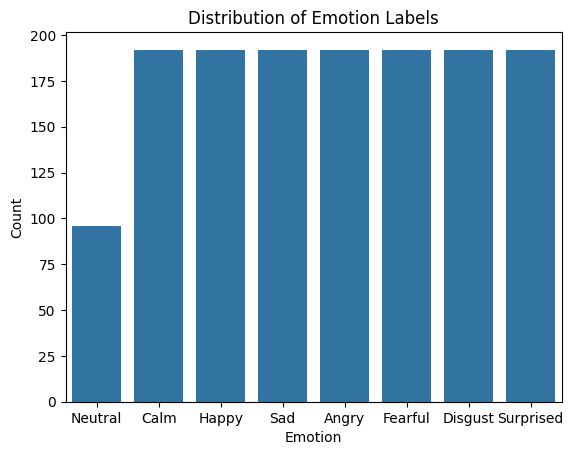

In [14]:
Ravdess = "dataset\\ravdess\\"

data = []

emotion_map = {
    1: "Neutral",
    2: "Calm",
    3: "Happy",
    4: "Sad",
    5: "Angry",
    6: "Fearful",
    7: "Disgust",
    8: "Surprised",
}

for dir in os.listdir(Ravdess):
    for file in os.listdir(os.path.join(Ravdess, dir)):
        filename, _ = os.path.splitext(file)
        parts = filename.split("-")
        emotion_code = int(parts[2])
        emotion = emotion_map.get(emotion_code, "Unknown")
        path = os.path.join(Ravdess, dir, file)
        data.append([path, emotion])

Ravdess_df = pd.DataFrame(data, columns=["path", "emotion"])

sns.countplot(x=Ravdess_df["emotion"])
plt.title("Distribution of Emotion Labels")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

**Output Dataframe to CSV**


In [15]:
def create_csv(df: pd.DataFrame, filename: str):
    csv_dir = "CSVs\\"

    if not os.path.exists(csv_dir):
        os.makedirs(csv_dir)
        print(f"Directory {csv_dir} created.")

    df.to_csv(os.path.join(csv_dir, filename), index=False)

    print(f"CSV file created at: {os.path.join(csv_dir, filename)}")


create_csv(Ravdess_df, "ravdess.csv")

CSV file created at: CSVs\ravdess.csv


**Silence Removal**


In [17]:
AudioSegment.converter = which("ffmpeg")

dataset = pd.read_csv("CSVs\\ravdess.csv")

location = "Ravdess_Silence\\"


def detect_leading_silence(dls_audio):
    dls_chunk_size = 10
    dls_silence_threshold = -50.0

    trim_ms = 0
    dls_audio_length = len(dls_audio)

    while trim_ms < dls_audio_length:
        chunk_dBFS = dls_audio[trim_ms : trim_ms + dls_chunk_size].dBFS
        if chunk_dBFS > dls_silence_threshold:
            break
        trim_ms += dls_chunk_size

    return trim_ms


name = 0
errors = 0
file_data = []

for _, row in dataset.iterrows():
    file_name = f"{location}{name}.wav"

    try:
        audio = AudioSegment.from_file(row["path"], format="wav")
    except:  # noqa: E722
        audio = AudioSegment.from_file(row["path"])

    start_trim = detect_leading_silence(audio)
    end_trim = detect_leading_silence(audio.reverse())

    duration = len(audio)
    new_audio = audio[start_trim : duration - end_trim]

    if len(new_audio) > 0:
        os.makedirs(os.path.dirname(file_name), exist_ok=True)
        new_audio.export(file_name, format="wav")
    else:
        audio.export(file_name, format="wav")
        errors += 1
        print(f"Error processing {row['path']}, saved original audio.")

    file_data.append([file_name, row["emotion"]])
    name += 1

Ravdess_silence = pd.DataFrame(file_data, columns=["path", "emotion"])
create_csv(Ravdess_silence, "ravdess_silence_removed.csv")

Error processing dataset\ravdess\Actor_09\03-01-02-02-01-02-09.wav, saved original audio.
Error processing dataset\ravdess\Actor_09\03-01-04-01-01-01-09.wav, saved original audio.
Error processing dataset\ravdess\Actor_09\03-01-04-01-02-02-09.wav, saved original audio.
Error processing dataset\ravdess\Actor_09\03-01-06-01-01-01-09.wav, saved original audio.
Error processing dataset\ravdess\Actor_20\03-01-02-02-01-01-20.wav, saved original audio.
Error processing dataset\ravdess\Actor_20\03-01-02-02-01-02-20.wav, saved original audio.
Error processing dataset\ravdess\Actor_20\03-01-02-02-02-01-20.wav, saved original audio.
Error processing dataset\ravdess\Actor_20\03-01-02-02-02-02-20.wav, saved original audio.
Error processing dataset\ravdess\Actor_20\03-01-04-01-01-02-20.wav, saved original audio.
Error processing dataset\ravdess\Actor_20\03-01-04-01-02-02-20.wav, saved original audio.
CSV file created at: CSVs\ravdess_silence_removed.csv


**Data augmentation**


In [21]:
Ravdess_silence = pd.read_csv("CSVs\\ravdess_silence_removed.csv")
location = "Ravdess_Augmented\\"
os.makedirs(location, exist_ok=True)

def noise(n_data):
    noise_amp = 0.04 * np.random.uniform() * np.amax(n_data)
    return n_data + noise_amp * np.random.normal(size=n_data.shape[0])


def stretch(s_data):
    s_rate = 0.8
    return librosa.effects.time_stretch(s_data, rate=s_rate)


def pitch(p_data, p_sampling_rate):
    p_pitch_factor = 0.7
    return librosa.effects.pitch_shift(
        p_data, sr=p_sampling_rate, n_steps=p_pitch_factor
    )


name = 0
file_data = []

for _, row in Ravdess_silence.iterrows():
    # Original audio
    file_name = f"{location}{name}.wav"
    print(f"Processing {file_name}")

    data, sampling_rate = librosa.load(row["path"])
    sf.write(file_name, data, sampling_rate)

    file_data.append([file_name, row["emotion"]])
    name += 1

    # Noise augmented audio
    file_name = f"{location}{name}.wav"
    print(f"Processing {file_name}")

    data_noise = noise(data)
    sf.write(file_name, data_noise, sampling_rate)

    file_data.append([file_name, row["emotion"]])
    name += 1

    # Time stretch augmented audio
    file_name = f"{location}{name}.wav"
    print(f"Processing {file_name}")

    data_stretch = stretch(data)
    sf.write(file_name, data_stretch, sampling_rate)

    file_data.append([file_name, row["emotion"]])
    name += 1

    # Pitch augmented audio
    file_name = f"{location}{name}.wav"
    print(f"Processing {file_name}")

    data_pitch = pitch(data, sampling_rate)
    sf.write(file_name, data_pitch, sampling_rate)

    file_data.append([file_name, row["emotion"]])
    name += 1


Ravdess_augmented = pd.DataFrame(file_data, columns=["path", "emotion"])
create_csv(Ravdess_augmented, "ravdess_augmented.csv")

Processing Ravdess_Augmented\0.wav
Processing Ravdess_Augmented\1.wav
Processing Ravdess_Augmented\2.wav
Processing Ravdess_Augmented\3.wav
Processing Ravdess_Augmented\4.wav
Processing Ravdess_Augmented\5.wav
Processing Ravdess_Augmented\6.wav
Processing Ravdess_Augmented\7.wav
Processing Ravdess_Augmented\8.wav
Processing Ravdess_Augmented\9.wav
Processing Ravdess_Augmented\10.wav
Processing Ravdess_Augmented\11.wav
Processing Ravdess_Augmented\12.wav
Processing Ravdess_Augmented\13.wav
Processing Ravdess_Augmented\14.wav
Processing Ravdess_Augmented\15.wav
Processing Ravdess_Augmented\16.wav
Processing Ravdess_Augmented\17.wav
Processing Ravdess_Augmented\18.wav
Processing Ravdess_Augmented\19.wav
Processing Ravdess_Augmented\20.wav
Processing Ravdess_Augmented\21.wav
Processing Ravdess_Augmented\22.wav
Processing Ravdess_Augmented\23.wav
Processing Ravdess_Augmented\24.wav
Processing Ravdess_Augmented\25.wav
Processing Ravdess_Augmented\26.wav
Processing Ravdess_Augmented\27.wav
Pr

d:\Coding\Projects\private_PRJ\speech-emotion-recognition-ravdess\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=596
  warnings.warn(


Processing Ravdess_Augmented\1977.wav
Processing Ravdess_Augmented\1978.wav
Processing Ravdess_Augmented\1979.wav
Processing Ravdess_Augmented\1980.wav
Processing Ravdess_Augmented\1981.wav
Processing Ravdess_Augmented\1982.wav
Processing Ravdess_Augmented\1983.wav
Processing Ravdess_Augmented\1984.wav
Processing Ravdess_Augmented\1985.wav
Processing Ravdess_Augmented\1986.wav
Processing Ravdess_Augmented\1987.wav
Processing Ravdess_Augmented\1988.wav
Processing Ravdess_Augmented\1989.wav
Processing Ravdess_Augmented\1990.wav
Processing Ravdess_Augmented\1991.wav
Processing Ravdess_Augmented\1992.wav
Processing Ravdess_Augmented\1993.wav
Processing Ravdess_Augmented\1994.wav
Processing Ravdess_Augmented\1995.wav
Processing Ravdess_Augmented\1996.wav
Processing Ravdess_Augmented\1997.wav
Processing Ravdess_Augmented\1998.wav
Processing Ravdess_Augmented\1999.wav
Processing Ravdess_Augmented\2000.wav
Processing Ravdess_Augmented\2001.wav
Processing Ravdess_Augmented\2002.wav
Processing R

d:\Coding\Projects\private_PRJ\speech-emotion-recognition-ravdess\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1257
  warnings.warn(


Processing Ravdess_Augmented\2027.wav
Processing Ravdess_Augmented\2028.wav
Processing Ravdess_Augmented\2029.wav
Processing Ravdess_Augmented\2030.wav
Processing Ravdess_Augmented\2031.wav
Processing Ravdess_Augmented\2032.wav
Processing Ravdess_Augmented\2033.wav
Processing Ravdess_Augmented\2034.wav
Processing Ravdess_Augmented\2035.wav
Processing Ravdess_Augmented\2036.wav
Processing Ravdess_Augmented\2037.wav
Processing Ravdess_Augmented\2038.wav
Processing Ravdess_Augmented\2039.wav
Processing Ravdess_Augmented\2040.wav
Processing Ravdess_Augmented\2041.wav
Processing Ravdess_Augmented\2042.wav
Processing Ravdess_Augmented\2043.wav
Processing Ravdess_Augmented\2044.wav
Processing Ravdess_Augmented\2045.wav
Processing Ravdess_Augmented\2046.wav
Processing Ravdess_Augmented\2047.wav
Processing Ravdess_Augmented\2048.wav
Processing Ravdess_Augmented\2049.wav
Processing Ravdess_Augmented\2050.wav
Processing Ravdess_Augmented\2051.wav
Processing Ravdess_Augmented\2052.wav
Processing R

d:\Coding\Projects\private_PRJ\speech-emotion-recognition-ravdess\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=155
  warnings.warn(


Processing Ravdess_Augmented\4603.wav
Processing Ravdess_Augmented\4604.wav
Processing Ravdess_Augmented\4605.wav
Processing Ravdess_Augmented\4606.wav
Processing Ravdess_Augmented\4607.wav
Processing Ravdess_Augmented\4608.wav
Processing Ravdess_Augmented\4609.wav
Processing Ravdess_Augmented\4610.wav
Processing Ravdess_Augmented\4611.wav
Processing Ravdess_Augmented\4612.wav
Processing Ravdess_Augmented\4613.wav
Processing Ravdess_Augmented\4614.wav
Processing Ravdess_Augmented\4615.wav
Processing Ravdess_Augmented\4616.wav
Processing Ravdess_Augmented\4617.wav
Processing Ravdess_Augmented\4618.wav
Processing Ravdess_Augmented\4619.wav
Processing Ravdess_Augmented\4620.wav
Processing Ravdess_Augmented\4621.wav
Processing Ravdess_Augmented\4622.wav
Processing Ravdess_Augmented\4623.wav
Processing Ravdess_Augmented\4624.wav
Processing Ravdess_Augmented\4625.wav
Processing Ravdess_Augmented\4626.wav
Processing Ravdess_Augmented\4627.wav
Processing Ravdess_Augmented\4628.wav
Processing R

d:\Coding\Projects\private_PRJ\speech-emotion-recognition-ravdess\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=221
  warnings.warn(


Processing Ravdess_Augmented\4671.wav
Processing Ravdess_Augmented\4672.wav
Processing Ravdess_Augmented\4673.wav
Processing Ravdess_Augmented\4674.wav
Processing Ravdess_Augmented\4675.wav
Processing Ravdess_Augmented\4676.wav
Processing Ravdess_Augmented\4677.wav
Processing Ravdess_Augmented\4678.wav
Processing Ravdess_Augmented\4679.wav
Processing Ravdess_Augmented\4680.wav
Processing Ravdess_Augmented\4681.wav
Processing Ravdess_Augmented\4682.wav
Processing Ravdess_Augmented\4683.wav
Processing Ravdess_Augmented\4684.wav
Processing Ravdess_Augmented\4685.wav
Processing Ravdess_Augmented\4686.wav
Processing Ravdess_Augmented\4687.wav
Processing Ravdess_Augmented\4688.wav
Processing Ravdess_Augmented\4689.wav
Processing Ravdess_Augmented\4690.wav
Processing Ravdess_Augmented\4691.wav
Processing Ravdess_Augmented\4692.wav
Processing Ravdess_Augmented\4693.wav
Processing Ravdess_Augmented\4694.wav
Processing Ravdess_Augmented\4695.wav
Processing Ravdess_Augmented\4696.wav
Processing R

**Dataset partitioning**


In [22]:
Ravdess_augmented = pd.read_csv("CSVs\\ravdess_augmented.csv")
X = Ravdess_augmented["path"]
y = Ravdess_augmented["emotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

create_csv(pd.DataFrame({"path": X_train, "emotion": y_train}), "ravdess_train.csv")
create_csv(pd.DataFrame({"path": X_val, "emotion": y_val}), "ravdess_val.csv")
create_csv(pd.DataFrame({"path": X_test, "emotion": y_test}), "ravdess_test.csv")

CSV file created at: CSVs\ravdess_train.csv
CSV file created at: CSVs\ravdess_val.csv
CSV file created at: CSVs\ravdess_test.csv
